In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score 

In [3]:
data = pd.read_csv("housing.csv")   
print("First 5 rows of the dataset:")   
data.head()

First 5 rows of the dataset:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
# Selecting independent variables (predictors) 
X = data[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',  
'Avg. Area Number of Bedrooms', 'Area Population']]   
# Selecting dependent variable (target) 
y = data['Price']   
# Check for missing values   
print("\nMissing values in the dataset:")   
print(data.isnull().sum())


Missing values in the dataset:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [6]:
# Initialize and train the multiple linear regression model 
model = LinearRegression()   
model.fit(X_train, y_train)   
# Print model parameters   
print("Intercept (β0):", model.intercept_)   
print("Coefficients (β1, β2, ..., βn):", model.coef_) 

Intercept (β0): -2635072.900915729
Coefficients (β1, β2, ..., βn): [2.16522058e+01 1.64666481e+05 1.19624012e+05 2.44037761e+03
 1.52703134e+01]


In [7]:
y_pred = model.predict(X_test)   
# Compare actual and predicted values 
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})   
print(comparison.head()) 

        Actual     Predicted
0  1339096.077  1.308588e+06
1  1251794.179  1.237037e+06
2  1340094.966  1.243429e+06
3  1431507.623  1.228900e+06
4  1042373.524  1.063321e+06


In [8]:
mse = mean_squared_error(y_test, y_pred)   
r2 = r2_score(y_test, y_pred)   
print("\nModel Evaluation Metrics:")   
print("Mean Squared Error (MSE):", mse)   
print("R-squared (R²):", r2)


Model Evaluation Metrics:
Mean Squared Error (MSE): 10089009299.497482
R-squared (R²): 0.9179971706985478


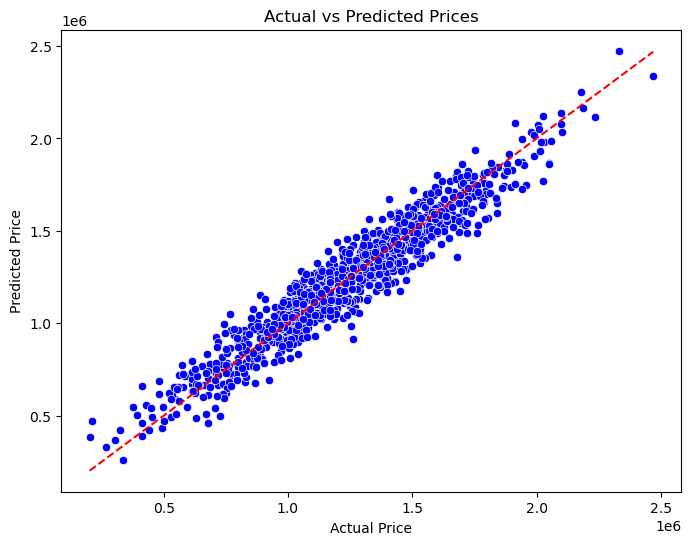

In [11]:
 #Plot Actual vs Predicted values 
plt.figure(figsize=(8,6)) 
sns.scatterplot(x=y_test, y=y_pred, color="blue") 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--") 
plt.xlabel("Actual Price") 
plt.ylabel("Predicted Price") 
plt.title("Actual vs Predicted Prices") 
plt.show() 

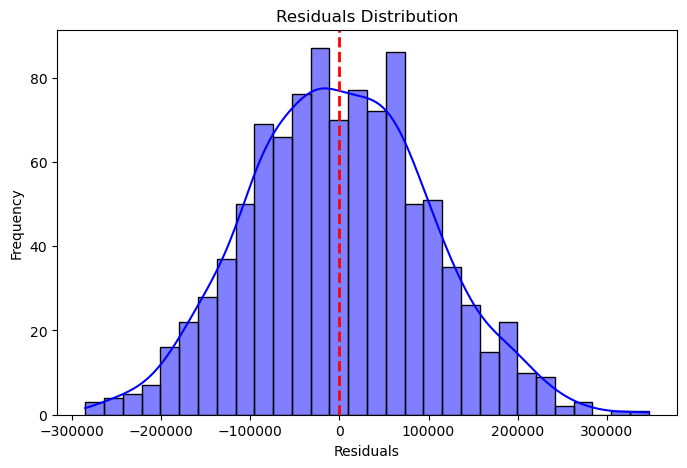

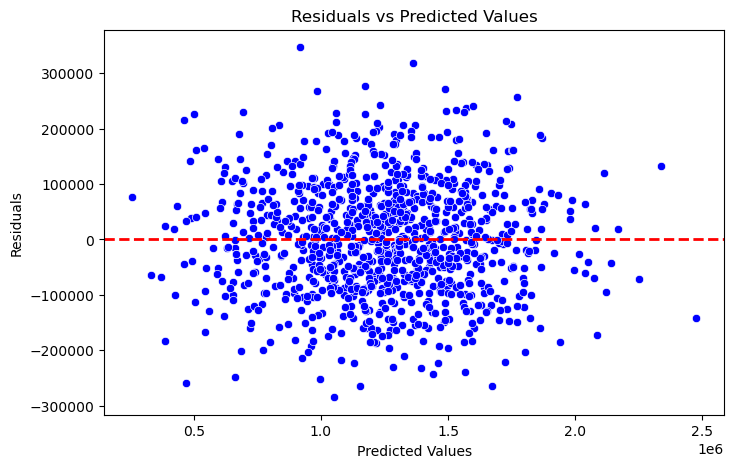

In [12]:
# Residuals Calculation
residuals = y_test - y_pred

# Plot 1: Histogram of Residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")
plt.show()

# Plot 2: Residuals vs. Predicted Values (Checking for patterns)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, color="blue")
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


# LAB QUESTIONS

### 1️⃣ What does each coefficient indicate?  
Each coefficient in a regression model represents the impact of a **one-unit increase** in the respective feature on the predicted house price, while keeping other features constant.  

- A **positive coefficient** means that increasing this feature will lead to a **higher predicted price**.  
- A **negative coefficient** means that increasing this feature will lead to a **lower predicted price**.  

The model assigns a weight (**coefficient**) to each feature, and these values help understand which factors **influence house prices the most**.


### 2️⃣ How well does the model predict Price?  
The model’s performance is measured using the **R² Score**, which indicates how much of the variance in house prices is explained by the selected features.  

#### 📊 **R² Score Interpretation:**  
- **R² = 1** → Perfect prediction. ✅  
- **R² > 0.80** → Strong predictive power. 🔥  
- **R² between 0.50 and 0.80** → Moderate predictive power. ⚖️  
- **R² < 0.50** → Weak predictive power; the model may be missing important predictors. ❌  


### 3️⃣ Are there patterns in residuals violating regression assumptions?  
Residuals are the difference between **actual** and **predicted** prices. They help in understanding whether the model meets regression assumptions.  

✅ **If residuals are randomly distributed around zero:**  
- The model is **well-fitted**, and assumptions hold.  

❌ **If residuals show patterns** (e.g., funnel shape, curves, or increasing variance):  
- The model may violate regression assumptions, indicating potential **heteroscedasticity** or **non-linearity**.  


# QQ Plot

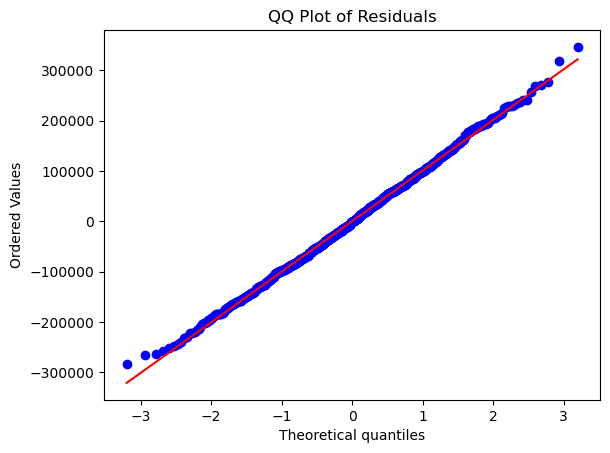

In [15]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()
